# Overview

**Pipeline Comparison**

This notebook compares **five progressive pipelines** (from early baselines to more structured agentic systems) tested on a **balanced Fakeddit subset (N=150; 75 Fake / 75 Real)** for the Fake News Detection project. Each pipeline produces intermediate tool/agent outputs and a final binary prediction *(Fake=0 / Real=1)*.<br><br>

1. **01_I2TFv1 — Image-to-Text Fusion (v1, Base)**  
   A first fusion baseline:
   - BLIP-generated (base) image caption is fused with the news headline.
   - Both are fed into RoBERTa (base) and a similarity model, and an LLM fuses the resulting scores.  
   
   Prompts and fusion logic are relatively simple and loosely guided.

2. **02_I2TFv2 — Image-to-Text Fusion (v2, Upgraded)**  
   Same architecture and overall idea as v1, but with:
   - BLIP-2 captioning (instead of base BLIP), and
   - Fakeddit-tuned RoBERTa (instead of base detector) for text.  
   
   Prompts and fusion logic are still relatively simple and loosely guided.

3. **03_SAFb — Single-Agent Fusion (Blind)**  
   A **LangChain** tool-calling agent that:
   - reads headline + BLIP-2 caption,
   - calls vision / text / consistency tools,
   - reasons in phases (intuition → forensics → synthesis),  
   - but **never sees the image directly**.  
   
   The LLM fuses all tool outputs inside a single "brain".

4. **04_SAFv — Single-Agent Fusion (Vision-Enabled)**  
   Same agent architecture as SAFb, but now:
   - the LLM **sees the image** directly (multimodal input),
   - the Text Tool focuses on the **headline only**,
   - the Consistency Tool drops image-caption alignment.  
   
   This makes fusion more genuinely multimodal and reduces noise from the BLIP-2 caption.

5. **05_MAH — Multi-Agent Hierarchical**  
   A **multi-agent panel of experts**, built on **LangGraph**:
   - a **Vision Agent** (image + vision tools),
   - a **Text Agent** (headline + text tools),
   - a **Context Agent** (headline + caption + alignment tools),
   - a **Judge Agent** that (has access to image + headline) reads the three reports and issues a final verdict.  

   All agents follow a shared three-phase discipline (intuition → forensics → synthesis), but specialize on different modalities. The goal is not only accuracy, but also **interpretability** via structured, per-agent reports and a transparent final decision.



<br>

**Evaluation**
- **Per-pipeline:** accuracy, confusion matrices, and classification reports for each tracked component (tools/agents).
- **Across pipelines:** compares only the final prediction of each pipeline.
- **Runtime:** measured per pipeline on NVIDIA L4 (driver 550.54.15, VRAM 23034 MiB) and summarized as total runtime (min) and seconds per sample.
<br>

**Saved outputs**
At the end, the notebook exports:
- `target_metrics.csv` (per-pipeline, per-target component stats)
- `final_metrics.csv` (final decision stats per pipeline)
- `runtime_metrics.csv` (runtime + latency stats per pipeline)
- `benchmark_table.csv` (merged performance + runtime table)
- `hardware_note.csv` (GPU specs)

# Setup

In [1]:
# Install dependencies
!pip -q install scikit-learn seaborn


In [2]:
# Clone the project repo
!git clone https://github.com/gizayceylan/FakeNews.git

# Add it to Python path
import sys
sys.path.append("/content/FakeNews")


Cloning into 'FakeNews'...
remote: Enumerating objects: 306, done.
remote: Counting objects: 100% (135/135), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 306 (delta 62), reused 66 (delta 24), pack-reused 171 (from 1)
Receiving objects: 100% (306/306), 20.20 MiB | 14.69 MiB/s, done.
Resolving deltas: 100% (150/150), done.


In [3]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import json

from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import files

# Data

In [4]:
# Set base paths
ROOT = "FakeNews/Comparison"
EVAL_DIR = os.path.join(ROOT, "eval")
RES_DIR  = os.path.join(ROOT, "results")
RUN_DIR  = os.path.join(ROOT, "runtime")

# Register file paths per pipeline
PIPELINES = {
    "01_I2TFv1": {
        "eval": os.path.join(EVAL_DIR, "01_I2TFv1_eval_df.csv"),
        "results": os.path.join(RES_DIR, "01_I2TFv1_results_df.csv"),
        "runtime": os.path.join(RUN_DIR, "01_I2TFv1_runtime_log.jsonl"),
    },
    "02_I2TFv2": {
        "eval": os.path.join(EVAL_DIR, "02_I2TFv2_eval_df.csv"),
        "results": os.path.join(RES_DIR, "02_I2TFv2_results_df.csv"),
        "runtime": os.path.join(RUN_DIR, "02_I2TFv2_runtime_log.jsonl"),
    },
    "03_SAFb": {
        "eval": os.path.join(EVAL_DIR, "03_SAFb_eval_df.csv"),
        "results": os.path.join(RES_DIR, "03_SAFb_results_df.csv"),
        "runtime": os.path.join(RUN_DIR, "03_SAFb_runtime_log.jsonl"),
    },
    "04_SAFv": {
        "eval": os.path.join(EVAL_DIR, "04_SAFv_eval_df.csv"),
        "results": os.path.join(RES_DIR, "04_SAFv_results_df.csv"),
        "runtime": os.path.join(RUN_DIR, "04_SAFv_runtime_log.jsonl"),
    },
    "05_MAH": {
        "eval": os.path.join(EVAL_DIR, "05_MAH_eval_df.csv"),
        "results": os.path.join(RES_DIR, "05_MAH_results_df.csv"),
        "runtime": os.path.join(RUN_DIR, "05_MAH_runtime_log.jsonl"),
    },
}


In [5]:
# Load files into a single container
records = {}

for key, paths in PIPELINES.items():
    eval_df = pd.read_csv(paths["eval"])
    results_df = pd.read_csv(paths["results"])
    runtime_df = pd.read_json(paths["runtime"], lines=True)

    records[key] = {"eval": eval_df, "results": results_df, "runtime": runtime_df}

print("Loaded:", list(records.keys()))


Loaded: ['01_I2TFv1', '02_I2TFv2', '03_SAFb', '04_SAFv', '05_MAH']


In [6]:
# Sanity check: eval and results should match per pipeline
for k, v in records.items():
    assert len(v["eval"]) == len(v["results"]), f"{k}: eval_df and results_df row count mismatch!"

# Sanity check: all pipelines should have same number of samples
nset = {k: len(v["eval"]) for k, v in records.items()}
print("\nRow counts:", nset)
assert len(set(nset.values())) == 1, "Mismatch in number of samples across pipelines!"

# File shape summary
print("\nFile shapes in each pipeline:")
for k,v in records.items():
    print(k, v["eval"].shape, v["results"].shape, v["runtime"].shape)



Row counts: {'01_I2TFv1': 150, '02_I2TFv2': 150, '03_SAFb': 150, '04_SAFv': 150, '05_MAH': 150}

File shapes in each pipeline:
01_I2TFv1 (150, 4) (150, 13) (1, 6)
02_I2TFv2 (150, 4) (150, 13) (1, 6)
03_SAFb (150, 6) (150, 15) (1, 6)
04_SAFv (150, 5) (150, 14) (1, 6)
05_MAH (150, 7) (150, 34) (1, 6)


# Evaluation (within pipelines)

In [7]:
# Map target columns
EVAL_TARGETS = {
    "01_I2TFv1": [
        ("text_label",    "RoBERTa (Headline)"),
        ("caption_label", "RoBERTa (Caption)"),
        ("llm_label",     "GPT (Fusion)"),
    ],
    "02_I2TFv2": [
        ("text_label",    "RoBERTa (Headline)"),
        ("caption_label", "RoBERTa (Caption)"),
        ("llm_label",     "GPT (Fusion)"),
    ],
    "03_SAFb": [
        ("clip_label",     "CLIP (Image)"),
        ("robertaT_label", "RoBERTa (Headline)"),
        ("robertaC_label", "RoBERTa (Caption)"),
        ("gpt_pre",        "GPT (Pre-Fusion)"),
        ("gpt_post",       "GPT (Post-Fusion)"),
    ],
    "04_SAFv": [
        ("clip_label",     "CLIP (Image)"),
        ("robertaT_label", "RoBERTa (Headline)"),
        ("gpt_pre",        "GPT (Pre-Fusion)"),
        ("gpt_post",       "GPT (Post-Fusion)"),
    ],
    "05_MAH": [
        ("va_pre",  "Vision Agent (Pre)"),
        ("va_post", "Vision Agent (Post)"),
        ("ta_pre",  "Text Agent (Pre)"),
        ("ta_post", "Text Agent (Post)"),
        ("ja_pre",  "Judge Agent (Pre)"),
        ("ja_post", "Judge Agent (Post)"),
    ],
}

TRUE_COL = "true_label"

In [8]:
# Helper for Accuracies
def acc_for_pipeline(key):
    """
    Compute and display per-target metrics (accuracy) for the specified pipeline.

    Usage:
        acc_for_pipeline("01_I2TFv1")
    """
    df = records[key]["eval"].copy()
    n_real = int((df[TRUE_COL].astype(int) == 1).sum())
    targets = EVAL_TARGETS[key]
    print("\n" + "-"*70)
    print(f"{key} — Accuracies | {len(df)} Samples | {n_real} Real")
    print("-"*70)

    for col, name in targets:
        acc = accuracy_score(df[TRUE_COL].astype(int), df[col].astype(int))
        print(f"{name} accuracy: {acc:.3f}")


In [9]:
# Helper for Classification Reports
def clasrep_for_pipeline(key):
    """
    Compute and display per-target metrics (classification report) for the specified pipeline.

    Usage:
        clasrep_for_pipeline("01_I2TFv1")
    """
    print(f"{key} — Classification Reports")
    df = records[key]["eval"].copy()
    targets = EVAL_TARGETS[key]

    for col, name in targets:
        print("\n" + "-"*70)
        print(f"{name} — Classification Report")
        print("-"*70)
        print(classification_report(
            df[TRUE_COL].astype(int),
            df[col].astype(int),
            labels=[0,1],
            target_names=["Fake", "Real"],
            zero_division=0
        ))

In [10]:
# Map plot colors
CMAPS = {
    "text_label": "Purples",
    "caption_label": "Purples",
    "llm_label": "Greens",
    "clip_label": "Blues",
    "robertaT_label": "Purples",
    "robertaC_label": "Purples",
    "gpt_pre": "Greens",
    "gpt_post": "Greens",
    "va_pre": "Blues",
    "va_post": "Blues",
    "ta_pre": "Purples",
    "ta_post": "Purples",
    "ja_pre": "Greens",
    "ja_post": "Greens",
}

# Helper for Confusion Matrice
def cm_for_pipeline(key, ncols=3, default_cmap="Blues"):
    """
    Plot confusion-matrix heatmaps for all evaluation targets of a pipeline.

    Usage:
        cm_for_pipeline("01_I2TFv1")
        cm_for_pipeline("05_MAH", ncols=2)
    """
    df = records[key]["eval"].copy()
    targets = EVAL_TARGETS.get(key, [])

    n = len(targets)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for i, (col, name) in enumerate(targets):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        cm = confusion_matrix(df[TRUE_COL].astype(int), df[col].astype(int), labels=[0,1])
        cmap = CMAPS.get(col, default_cmap)

        sns.heatmap(
            cm, annot=True, fmt="d", cbar=True, cmap=cmap,
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            vmin=0, vmax=75, ax=ax
        )
        ax.set_title(f"{name}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    # Turn off unused axes
    for j in range(n, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    fig.suptitle(f"{key} — Confusion Matrices", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [11]:
# Helper for structured stats
def stats_for_pipeline(key):
    """
    Return per-target stats (accuracy, macro-F1, TP/FP/TN/FN) for one pipeline.

    Usage:
        stats_for_pipeline("01_I2TFv1")
    """
    df = records[key]["eval"].copy()
    y_true = df[TRUE_COL].astype(int).values
    targets = EVAL_TARGETS[key]

    rows = []
    for col, name in targets:
        y_pred = df[col].astype(int).values
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred, labels=[0,1])  # [[tn,fp],[fn,tp]]
        tn, fp, fn, tp = cm.ravel()
        counts_str = f"{int(tn)}/{int(fp)}/{int(fn)}/{int(tp)}"
        rep = classification_report(y_true, y_pred, labels=[0,1], output_dict=True, zero_division=0)
        macro_f1 = rep["macro avg"]["f1-score"]
        fake_precision = rep["0"]["precision"]
        fake_recall    = rep["0"]["recall"]
        fake_f1        = rep["0"]["f1-score"]
        real_precision = rep["1"]["precision"]
        real_recall    = rep["1"]["recall"]
        real_f1        = rep["1"]["f1-score"]

        rows.append({
            "pipeline": key,
            "target_col": col,
            "target_name": name,
            "n_samples": int(len(df)),
            "accuracy": acc,
            "macro_f1": macro_f1,
            "fake_precision": fake_precision,
            "fake_recall": fake_recall,
            "fake_f1": fake_f1,
            "real_precision": real_precision,
            "real_recall": real_recall,
            "real_f1": real_f1,
            "tn_fp_fn_tp": counts_str,
        })

    return pd.DataFrame(rows)

## A. Early Pipelines  





### 01_I2TFv1: Image to Text Fusion (v1, base models)

**Goal:** Fuse evidence from image and text into a single Fake/Real decision.

**Inputs:** headline + image + BLIP caption.

**Core idea:** Combine vision-derived cues and text-based cues, then let an LLM produce the final label and short explanation.

**Note:** This is the earlier model stack; performance reflects both the fusion design and older base models.

**Model stack:**
- BLIP: `Salesforce/blip-image-captioning-base`
- RoBERTa: `roberta-base-openai-detector`
- MPNET: `all-mpnet-base-v2`
- GPT: `gpt-4.1-mini`

In [12]:
# Accuracies
acc_for_pipeline("01_I2TFv1")


----------------------------------------------------------------------
01_I2TFv1 — Accuracies | 150 Samples | 75 Real
----------------------------------------------------------------------
RoBERTa (Headline) accuracy: 0.560
RoBERTa (Caption) accuracy: 0.540
GPT (Fusion) accuracy: 0.600


In [13]:
# Classification reports
clasrep_for_pipeline("01_I2TFv1")

01_I2TFv1 — Classification Reports

----------------------------------------------------------------------
RoBERTa (Headline) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.55      0.65      0.60        75
        Real       0.57      0.47      0.51        75

    accuracy                           0.56       150
   macro avg       0.56      0.56      0.56       150
weighted avg       0.56      0.56      0.56       150


----------------------------------------------------------------------
RoBERTa (Caption) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.52      0.85      0.65        75
        Real       0.61      0.23      0.33        75

    accuracy                           0.54       150
   macro avg       0.57      0.54      0.49      

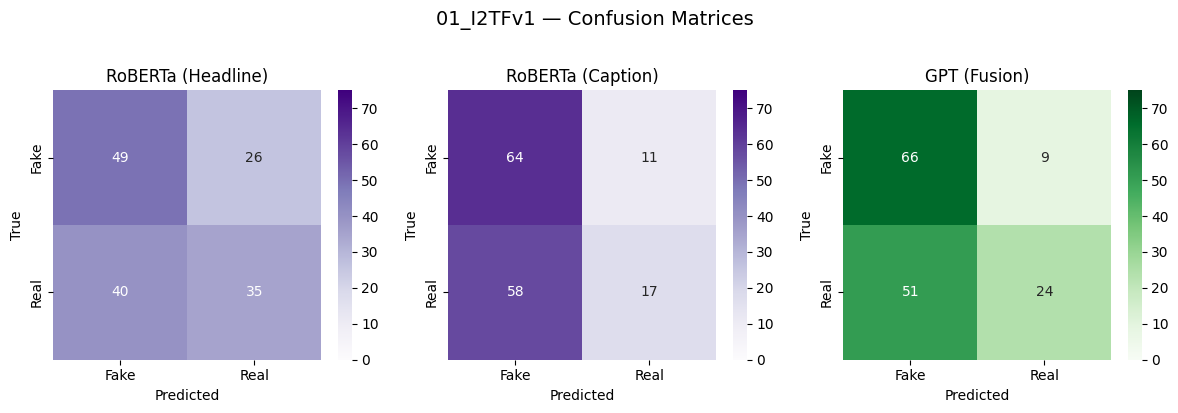

In [14]:
# Confusion Matrices (CM)
cm_for_pipeline("01_I2TFv1")

In [15]:
# Display stats
stats_for_pipeline("01_I2TFv1")

,pipeline,target_col,target_name,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,01_I2TFv1,text_label,RoBERTa (Headline),150,0.56,0.556133,0.550562,0.653333,0.597561,0.573770,0.466667,0.514706,49/26/40/35
1,01_I2TFv1,caption_label,RoBERTa (Caption),150,0.54,0.489922,0.524590,0.853333,0.649746,0.607143,0.226667,0.330097,64/11/58/17
2,01_I2TFv1,llm_label,GPT (Fusion),150,0.60,0.565972,0.564103,0.880000,0.687500,0.727273,0.320000,0.444444,66/9/51/24


### 02_I2TFv2: Image to Text Fusion (v2, upgraded models)

**Goal:** Same fusion architecture as v1, but with a stronger model stack to isolate the impact of model upgrades.

**Inputs:** headline + image + BLIP2 caption (consistent with later pipelines).

**Core idea:** Use improved text/vision signals and keep the same fusion workflow, then let an LLM decide Fake/Real.

**Note:** Useful for separating "architecture/prompting" vs "model quality" effects.

**Model stack:**
- BLIP-2: `Salesforce/blip2-opt-2.7b`
- RoBERTa: `yaoyinnan/roberta-fakeddit`
- MPNET: `all-mpnet-base-v2`
- GPT: `gpt-4.1-mini`


In [16]:
# Accuracies
acc_for_pipeline("02_I2TFv2")


----------------------------------------------------------------------
02_I2TFv2 — Accuracies | 150 Samples | 75 Real
----------------------------------------------------------------------
RoBERTa (Headline) accuracy: 0.940
RoBERTa (Caption) accuracy: 0.580
GPT (Fusion) accuracy: 0.747


In [17]:
# Classification Reports
clasrep_for_pipeline("02_I2TFv2")

02_I2TFv2 — Classification Reports

----------------------------------------------------------------------
RoBERTa (Headline) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.92      0.96      0.94        75
        Real       0.96      0.92      0.94        75

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
weighted avg       0.94      0.94      0.94       150


----------------------------------------------------------------------
RoBERTa (Caption) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.57      0.68      0.62        75
        Real       0.60      0.48      0.53        75

    accuracy                           0.58       150
   macro avg       0.58      0.58      0.58      

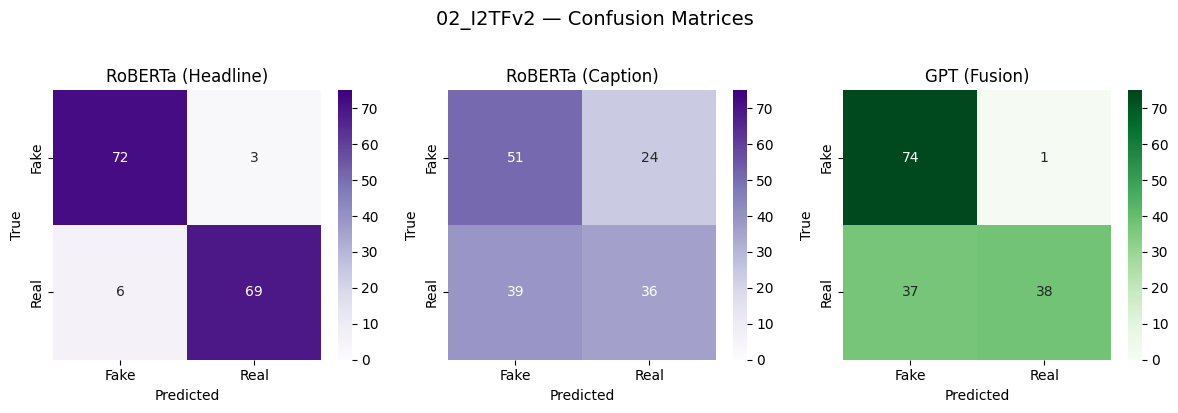

In [18]:
# Confusion Matrices (CM)
cm_for_pipeline("02_I2TFv2")

In [19]:
# Display stats
stats_for_pipeline("02_I2TFv2")

,pipeline,target_col,target_name,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,02_I2TFv2,text_label,RoBERTa (Headline),150,0.940000,0.939976,0.923077,0.960000,0.941176,0.958333,0.920000,0.938776,72/3/6/69
1,02_I2TFv2,caption_label,RoBERTa (Caption),150,0.580000,0.575758,0.566667,0.680000,0.618182,0.600000,0.480000,0.533333,51/24/39/36
2,02_I2TFv2,llm_label,GPT (Fusion),150,0.746667,0.731183,0.666667,0.986667,0.795699,0.974359,0.506667,0.666667,74/1/37/38


## B. Intermediate Pipelines

### 03_SAFb: Single-Agent Fusion (Blind)

**Goal:** A single LLM agent makes a Fake/Real decision by actively calling tools.

**Inputs:** headline + image (only for tool) + BLIP2 caption + visual concepts.

**Core idea:** The agent first forms an initial impression, then queries relevant tools (vision, text, context), and integrating tool results, produces a final label with rationale.

**Note:** Serves as a baseline for "agentic tool use" without visual access.

**Model stack:**
- BLIP-2: `Salesforce/blip2-opt-2.7b`
- CLIP: `openai/clip-vit-base-patch32`
- RoBERTa: `yaoyinnan/roberta-fakeddit`
- MPNET: `all-mpnet-base-v2`
- GPT: `gpt-4.1-mini`

In [20]:
# Accuracies
acc_for_pipeline("03_SAFb")


----------------------------------------------------------------------
03_SAFb — Accuracies | 150 Samples | 75 Real
----------------------------------------------------------------------
CLIP (Image) accuracy: 0.493
RoBERTa (Headline) accuracy: 0.940
RoBERTa (Caption) accuracy: 0.580
GPT (Pre-Fusion) accuracy: 0.800
GPT (Post-Fusion) accuracy: 0.740


In [21]:
# Classification reports
clasrep_for_pipeline("03_SAFb")

03_SAFb — Classification Reports

----------------------------------------------------------------------
CLIP (Image) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.48      0.19      0.27        75
        Real       0.50      0.80      0.61        75

    accuracy                           0.49       150
   macro avg       0.49      0.49      0.44       150
weighted avg       0.49      0.49      0.44       150


----------------------------------------------------------------------
RoBERTa (Headline) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.92      0.96      0.94        75
        Real       0.96      0.92      0.94        75

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
we

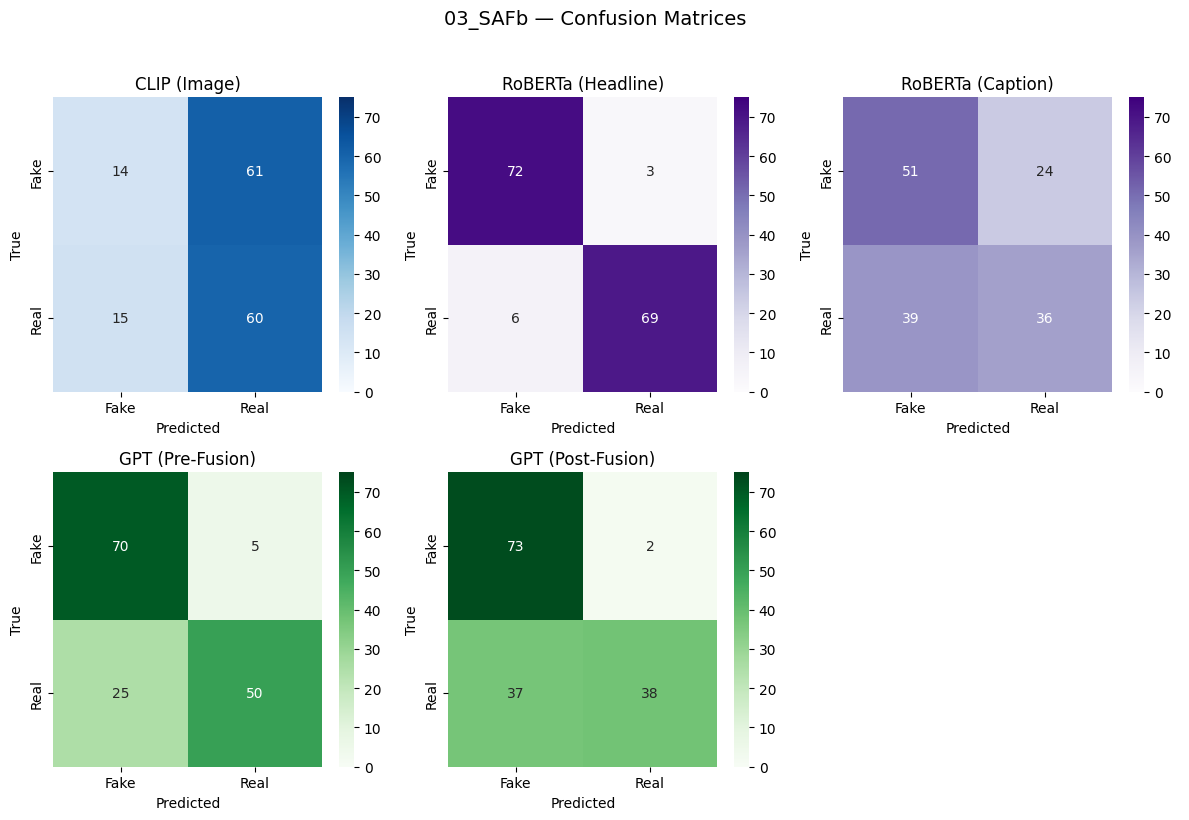

In [22]:
# Confusion Matrices (CM)
cm_for_pipeline("03_SAFb")

In [23]:
# Display stats
stats_for_pipeline("03_SAFb")

,pipeline,target_col,target_name,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,03_SAFb,clip_label,CLIP (Image),150,0.493333,0.440738,0.482759,0.186667,0.269231,0.495868,0.800000,0.612245,14/61/15/60
1,03_SAFb,robertaT_label,RoBERTa (Headline),150,0.940000,0.939976,0.923077,0.960000,0.941176,0.958333,0.920000,0.938776,72/3/6/69
2,03_SAFb,robertaC_label,RoBERTa (Caption),150,0.580000,0.575758,0.566667,0.680000,0.618182,0.600000,0.480000,0.533333,51/24/39/36
3,03_SAFb,gpt_pre,GPT (Pre-Fusion),150,0.800000,0.796380,0.736842,0.933333,0.823529,0.909091,0.666667,0.769231,70/5/25/50
4,03_SAFb,gpt_post,GPT (Post-Fusion),150,0.740000,0.725029,0.663636,0.973333,0.789189,0.950000,0.506667,0.660870,73/2/37/38


### 04_SAFv: Single-Agent Fusion (Vision-enabled)

**Goal:** Same single-agent tool-using setup, but with direct access to the image.

**Inputs:** headline + image + BLIP2 caption + visual concepts.

**Core idea:** Same idea, but the initial impression is formed using direct access to the image and headline. The agent then queries tools (vision, text, context) and produces a final revised decision with a rationale.

**Note:** Tests whether direct access to the image improves decisions compared to blind version.

**Model stack:**
- BLIP-2: `Salesforce/blip2-opt-2.7b`
- CLIP: `openai/clip-vit-base-patch32`
- RoBERTa: `yaoyinnan/roberta-fakeddit`
- MPNET: `all-mpnet-base-v2`
- GPT: `gpt-4.1-mini`

In [24]:
# Accuracies
acc_for_pipeline("04_SAFv")


----------------------------------------------------------------------
04_SAFv — Accuracies | 150 Samples | 75 Real
----------------------------------------------------------------------
CLIP (Image) accuracy: 0.493
RoBERTa (Headline) accuracy: 0.940
GPT (Pre-Fusion) accuracy: 0.633
GPT (Post-Fusion) accuracy: 0.833


In [25]:
# Classification reports
clasrep_for_pipeline("04_SAFv")

04_SAFv — Classification Reports

----------------------------------------------------------------------
CLIP (Image) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.48      0.19      0.27        75
        Real       0.50      0.80      0.61        75

    accuracy                           0.49       150
   macro avg       0.49      0.49      0.44       150
weighted avg       0.49      0.49      0.44       150


----------------------------------------------------------------------
RoBERTa (Headline) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.92      0.96      0.94        75
        Real       0.96      0.92      0.94        75

    accuracy                           0.94       150
   macro avg       0.94      0.94      0.94       150
we

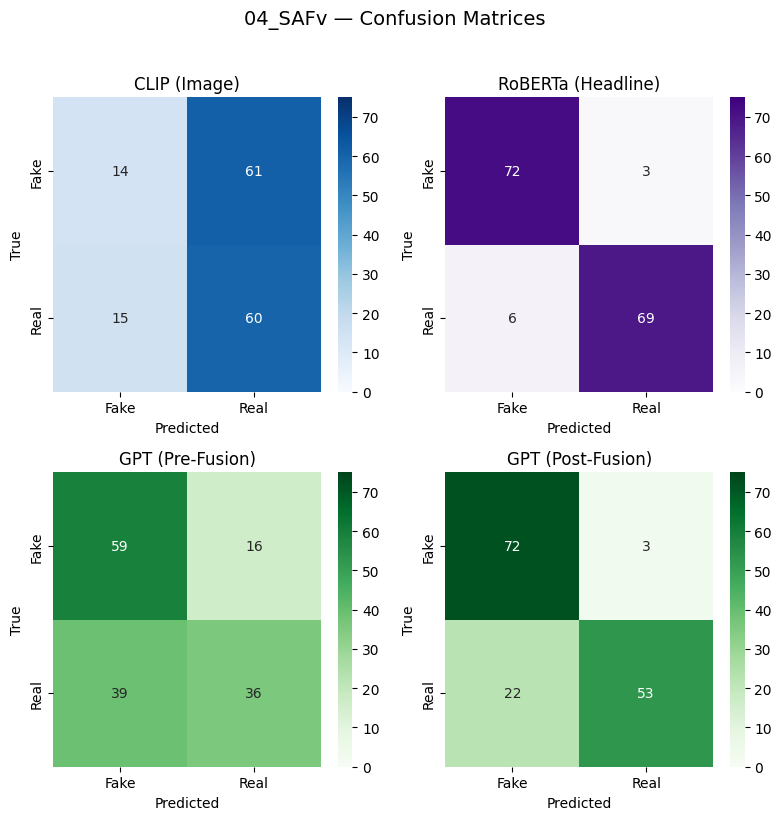

In [26]:
# Confusion Matrices (CM)
cm_for_pipeline("04_SAFv", ncols=2)

In [27]:
# Display stats
stats_for_pipeline("04_SAFv")

,pipeline,target_col,target_name,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,04_SAFv,clip_label,CLIP (Image),150,0.493333,0.440738,0.482759,0.186667,0.269231,0.495868,0.800000,0.612245,14/61/15/60
1,04_SAFv,robertaT_label,RoBERTa (Headline),150,0.940000,0.939976,0.923077,0.960000,0.941176,0.958333,0.920000,0.938776,72/3/6/69
2,04_SAFv,gpt_pre,GPT (Pre-Fusion),150,0.633333,0.624505,0.602041,0.786667,0.682081,0.692308,0.480000,0.566929,59/16/39/36
3,04_SAFv,gpt_post,GPT (Post-Fusion),150,0.833333,0.830616,0.765957,0.960000,0.852071,0.946429,0.706667,0.809160,72/3/22/53


## C. Final Pipeline

### 05_MAH: Multi-Agent Hierarchical

**Goal:** Decompose verification into specialized agents and aggregate them via a final judge.

**Inputs:** headline + image + BLIP2 caption + visual concepts + similarity/context signals.

**Core idea:** A judge agent forms an initial impression, then consults specialized agents (vision, text, context), and produces a final revised decision that explicitly synthesizes their evidence.

**Note:** Most structured/complex pipeline; aims to improve robustness and transparency through specialization.

**Models:**
- BLIP-2: `Salesforce/blip2-opt-2.7b`
- CLIP: `openai/clip-vit-base-patch32`
- RoBERTa: `yaoyinnan/roberta-fakeddit`
- MPNET: `all-mpnet-base-v2`
- GPT: `gpt-4.1-mini`

In [28]:
# Accuracies
acc_for_pipeline("05_MAH")


----------------------------------------------------------------------
05_MAH — Accuracies | 150 Samples | 75 Real
----------------------------------------------------------------------
Vision Agent (Pre) accuracy: 0.613
Vision Agent (Post) accuracy: 0.613
Text Agent (Pre) accuracy: 0.840
Text Agent (Post) accuracy: 0.913
Judge Agent (Pre) accuracy: 0.760
Judge Agent (Post) accuracy: 0.813


In [29]:
# Classification reports
clasrep_for_pipeline("05_MAH")

05_MAH — Classification Reports

----------------------------------------------------------------------
Vision Agent (Pre) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.67      0.45      0.54        75
        Real       0.59      0.77      0.67        75

    accuracy                           0.61       150
   macro avg       0.63      0.61      0.60       150
weighted avg       0.63      0.61      0.60       150


----------------------------------------------------------------------
Vision Agent (Post) — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.67      0.45      0.54        75
        Real       0.59      0.77      0.67        75

    accuracy                           0.61       150
   macro avg       0.63      0.61      0.60       

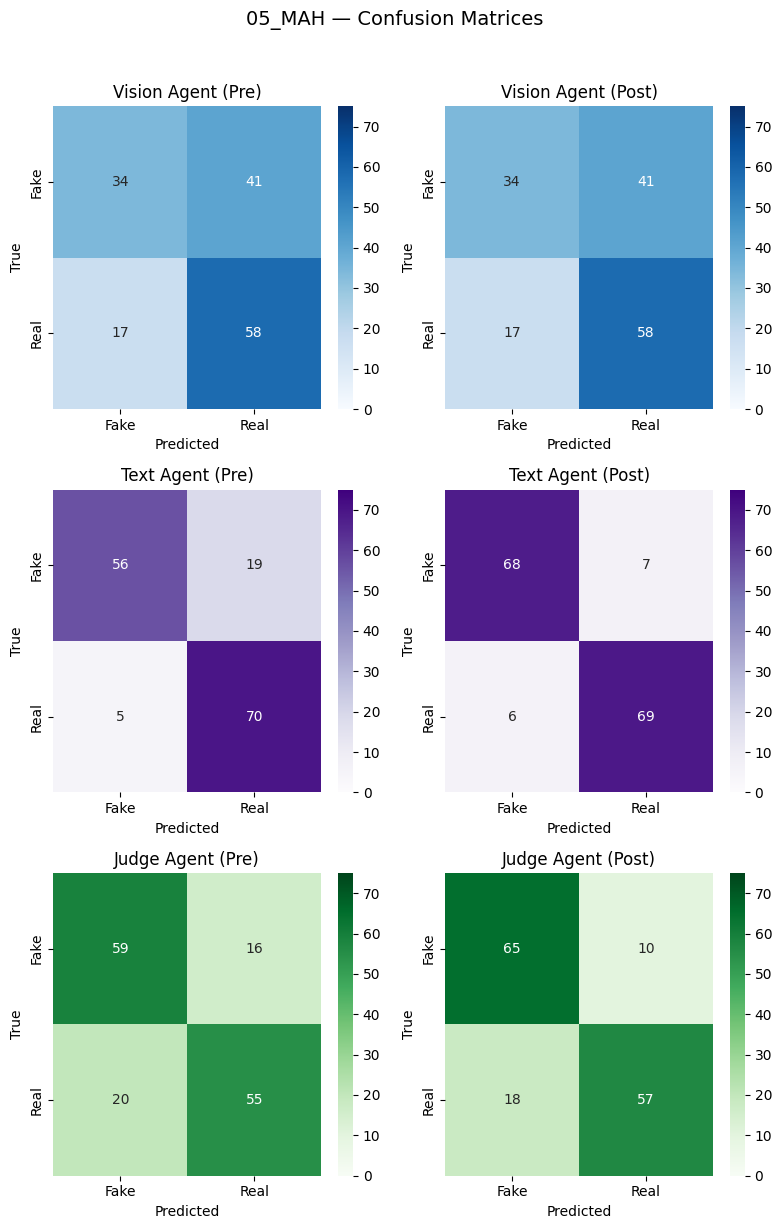

In [30]:
# Confusion Matrices (CM)
cm_for_pipeline("05_MAH", ncols=2)

In [31]:
# Display stats
stats_for_pipeline("05_MAH")

,pipeline,target_col,target_name,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,05_MAH,va_pre,Vision Agent (Pre),150,0.613333,0.603175,0.666667,0.453333,0.539683,0.585859,0.773333,0.666667,34/41/17/58
1,05_MAH,va_post,Vision Agent (Post),150,0.613333,0.603175,0.666667,0.453333,0.539683,0.585859,0.773333,0.666667,34/41/17/58
2,05_MAH,ta_pre,Text Agent (Pre),150,0.840000,0.838594,0.918033,0.746667,0.823529,0.786517,0.933333,0.853659,56/19/5/70
3,05_MAH,ta_post,Text Agent (Post),150,0.913333,0.913329,0.918919,0.906667,0.912752,0.907895,0.920000,0.913907,68/7/6/69
4,05_MAH,ja_pre,Judge Agent (Pre),150,0.760000,0.759829,0.746835,0.786667,0.766234,0.774648,0.733333,0.753425,59/16/20/55
5,05_MAH,ja_post,Judge Agent (Post),150,0.813333,0.812801,0.783133,0.866667,0.822785,0.850746,0.760000,0.802817,65/10/18/57


# Comparison (across pipelines)

In [32]:
# Map target columns (final decision in each pipeline)
EVAL_FINAL = {
    "01_I2TFv1": "llm_label",
    "02_I2TFv2": "llm_label",
    "03_SAFb":   "gpt_post",
    "04_SAFv":   "gpt_post",
    "05_MAH":    "ja_post",
}
TRUE_COL = "true_label"

In [33]:
# Helper for Accuracies
def final_acc_across_pipelines(records, keys=None):
    """
    Evaluate the final decision output for selected pipelines (accuracy).

    Args:
        records: dict like records[pipeline_key]["eval"] -> DataFrame
        keys: list of pipeline keys to evaluate. If None, evaluate all keys in EVAL_FINAL.

    Usage:
        final_acc_across_pipelines(records)  # all
        final_acc_across_pipelines(records, ["01_I2TFv1", "05_MAH"])  # subset
    """
    if keys is None:
        keys = list(EVAL_FINAL.keys())

    print("\n" + "="*70)
    print("Final accuracy comparison across selected pipelines:")
    print(keys)
    print("="*70)

    for k in keys:
        df = records[k]["eval"]
        y_true = df[TRUE_COL].astype(int).values
        pred_col = EVAL_FINAL[k]
        y_pred = df[pred_col].astype(int).values
        acc = accuracy_score(y_true, y_pred)
        print(f"{k} final accuracy: {acc:.3f}")


In [34]:
# Helper for Classification Reports
def final_clasrep_across_pipelines(records, keys=None):
    """
    Evaluate the final decision output for selected pipelines (classification report).

    Args:
        records: dict like records[pipeline_key]["eval"] -> DataFrame
        keys: list of pipeline keys to evaluate. If None, evaluate all keys in EVAL_FINAL.

    Usage:
        final_clasrep_across_pipelines(records)  # all
        final_clasrep_across_pipelines(records, ["01_I2TFv1", "05_MAH"])  # subset
    """
    if keys is None:
        keys = list(EVAL_FINAL.keys())

    print("\n" + "="*70)
    print("Final classification performance comparison across selected pipelines:")
    print(keys)
    print("="*70)

    for k in keys:
        df = records[k]["eval"]
        y_true = df[TRUE_COL].astype(int).values
        pred_col = EVAL_FINAL[k]
        y_pred = df[pred_col].astype(int).values
        print("\n" + "-"*70)
        print(f"{k} — Classification Report")
        print("-"*70)
        print(classification_report(
            y_true, y_pred,
            labels=[0,1],
            target_names=["Fake", "Real"],
            zero_division=0
        ))


In [35]:
# Helper for Confusion Matrice
def final_cm_across_pipelines(records, keys=None, ncols=2, cmap="Greens"):
    """
    Plot confusion-matrix heatmaps for the FINAL prediction of selected pipelines.

    Usage:
        final_cm_across_pipelines(records)  # all
        final_cm_across_pipelines(records, ["01_I2TFv1","05_MAH"], ncols=2)
    """
    if keys is None:
        keys = list(EVAL_FINAL.keys())

    n = len(keys)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
    axes = np.array(axes).reshape(nrows, ncols)

    for i, k in enumerate(keys):
        r, c = divmod(i, ncols)
        ax = axes[r, c]

        df = records[k]["eval"]
        y_true = df[TRUE_COL].astype(int).values

        pred_col = EVAL_FINAL[k]
        y_pred = df[pred_col].astype(int).values

        cm = confusion_matrix(y_true, y_pred, labels=[0,1])

        sns.heatmap(
            cm, annot=True, fmt="d", cmap=cmap, cbar=True,
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"],
            vmin=0, vmax=75, ax=ax
        )
        ax.set_title(f"{k}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    # hide unused axes
    for j in range(n, nrows*ncols):
        r, c = divmod(j, ncols)
        axes[r, c].axis("off")

    fig.suptitle(f"{keys} — Confusion Matrices", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [36]:
# Helper for structured stats
def final_stats_across_pipelines(keys=None):
    """
    Return final-decision stats across selected pipelines.

    Usage:
        final_stats_across_pipelines()  # all
        final_stats_across_pipelines(["01_I2TFv1","05_MAH"])
    """
    if keys is None:
        keys = list(EVAL_FINAL.keys())

    rows = []
    for k in keys:
        df = records[k]["eval"].copy()
        y_true = df[TRUE_COL].astype(int).values
        pred_col = EVAL_FINAL[k]
        y_pred = df[pred_col].astype(int).values
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred, labels=[0,1])
        tn, fp, fn, tp = cm.ravel()
        counts_str = f"{int(tn)}/{int(fp)}/{int(fn)}/{int(tp)}"
        rep = classification_report(y_true, y_pred, labels=[0,1], output_dict=True, zero_division=0)
        macro_f1       = rep["macro avg"]["f1-score"]
        fake_precision = rep["0"]["precision"]
        fake_recall    = rep["0"]["recall"]
        fake_f1        = rep["0"]["f1-score"]
        real_precision = rep["1"]["precision"]
        real_recall    = rep["1"]["recall"]
        real_f1        = rep["1"]["f1-score"]

        rows.append({
            "pipeline": k,
            "final_col": pred_col,
            "n_samples": int(len(df)),
            "accuracy": acc,
            "macro_f1": macro_f1,
            "fake_precision": fake_precision,
            "fake_recall": fake_recall,
            "fake_f1": fake_f1,
            "real_precision": real_precision,
            "real_recall": real_recall,
            "real_f1": real_f1,
            "tn_fp_fn_tp": counts_str,
        })

    return pd.DataFrame(rows)


In [37]:
# Helper for Runtime logs
def final_runtime_across_pipelines(keys=None):
    """
    Return final-runtime logs across selected pipelines.

    Usage:
        final_runtime_across_pipelines()  # all
        final_runtime_across_pipelines(["01_I2TFv1","05_MAH"])
    """
    if keys is None:
        keys = list(PIPELINES.keys())

    rows = []
    for k in keys:
        rt = records[k]["runtime"]
        r = rt.iloc[-1].to_dict()

        runtime_sec = float(r.get("runtime_sec", float("nan")))
        n_samples = int(r.get("n_samples", len(records[k]["eval"])))

        rows.append({
            "pipeline": k,
            "n_samples": n_samples,
            "runtime_sec": runtime_sec,
            "runtime_min": runtime_sec/60.0,
            "sec_per_sample": runtime_sec / max(n_samples, 1),
            "gpu_name": r.get("gpu_name", None),
            "driver_version": r.get("driver_version", None),
            "vram_total_mib": r.get("vram_total_mib", r.get("vram_total", None)),
        })

    return pd.DataFrame(rows)

## All or Selected

In [38]:
# Accuracies
final_acc_across_pipelines(records)


Final accuracy comparison across selected pipelines:
['01_I2TFv1', '02_I2TFv2', '03_SAFb', '04_SAFv', '05_MAH']
01_I2TFv1 final accuracy: 0.600
02_I2TFv2 final accuracy: 0.747
03_SAFb final accuracy: 0.740
04_SAFv final accuracy: 0.833
05_MAH final accuracy: 0.813


In [39]:
# Classification Reports
final_clasrep_across_pipelines(records)


Final classification performance comparison across selected pipelines:
['01_I2TFv1', '02_I2TFv2', '03_SAFb', '04_SAFv', '05_MAH']

----------------------------------------------------------------------
01_I2TFv1 — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.56      0.88      0.69        75
        Real       0.73      0.32      0.44        75

    accuracy                           0.60       150
   macro avg       0.65      0.60      0.57       150
weighted avg       0.65      0.60      0.57       150


----------------------------------------------------------------------
02_I2TFv2 — Classification Report
----------------------------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.67      0.99      0.80        75
        Real       0.97      0.51      0.67        75

    accuracy            

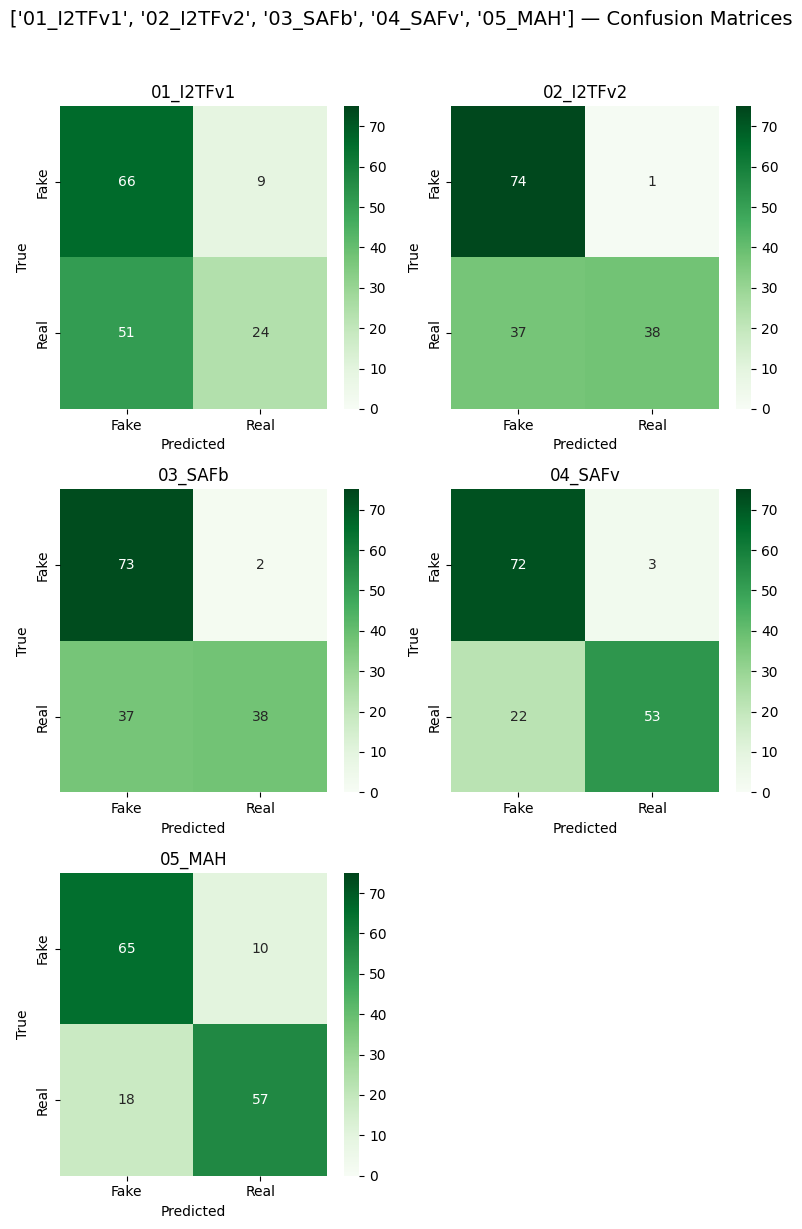

In [40]:
# Confusion Matrices (CM)
final_cm_across_pipelines(records, ncols=2)

In [41]:
# Display stats
final_stats_across_pipelines()

,pipeline,final_col,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,01_I2TFv1,llm_label,150,0.600000,0.565972,0.564103,0.880000,0.687500,0.727273,0.320000,0.444444,66/9/51/24
1,02_I2TFv2,llm_label,150,0.746667,0.731183,0.666667,0.986667,0.795699,0.974359,0.506667,0.666667,74/1/37/38
2,03_SAFb,gpt_post,150,0.740000,0.725029,0.663636,0.973333,0.789189,0.950000,0.506667,0.660870,73/2/37/38
3,04_SAFv,gpt_post,150,0.833333,0.830616,0.765957,0.960000,0.852071,0.946429,0.706667,0.809160,72/3/22/53
4,05_MAH,ja_post,150,0.813333,0.812801,0.783133,0.866667,0.822785,0.850746,0.760000,0.802817,65/10/18/57


In [43]:
# Display runtime logs
final_runtime_across_pipelines()

,pipeline,n_samples,runtime_sec,runtime_min,sec_per_sample,gpu_name,driver_version,vram_total_mib
0,01_I2TFv1,150,239.407556,3.990126,1.596050,NVIDIA L4,550.54.15,23034 MiB
1,02_I2TFv2,150,226.636060,3.777268,1.510907,NVIDIA L4,550.54.15,23034 MiB
2,03_SAFb,150,1029.206638,17.153444,6.861378,NVIDIA L4,550.54.15,23034 MiB
3,04_SAFv,150,1207.780928,20.129682,8.051873,NVIDIA L4,550.54.15,23034 MiB
4,05_MAH,150,1812.780385,30.213006,12.085203,NVIDIA L4,550.54.15,23034 MiB


# Save

In [44]:
# Create summary tables (per-target, final-only, runtime, and merged benchmark)
target_metrics_df = pd.concat([stats_for_pipeline(k) for k in PIPELINES.keys()], ignore_index=True)
final_metrics_df = final_stats_across_pipelines()
runtime_metrics_df = final_runtime_across_pipelines()

bench_df = final_metrics_df.merge(
    runtime_metrics_df[["pipeline","runtime_min","sec_per_sample"]],
    on="pipeline", how="left"
).drop(columns=["final_col"], errors="ignore")

env = runtime_metrics_df[["gpu_name","driver_version","vram_total_mib"]].drop_duplicates()

display(target_metrics_df.head(1))
display(final_metrics_df.head(1))
display(runtime_metrics_df.head(1))
display(bench_df.head(1))
display(env)

,pipeline,target_col,target_name,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,01_I2TFv1,text_label,RoBERTa (Headline),150,0.56,0.556133,0.550562,0.653333,0.597561,0.57377,0.466667,0.514706,49/26/40/35


,pipeline,final_col,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp
0,01_I2TFv1,llm_label,150,0.6,0.565972,0.564103,0.88,0.6875,0.727273,0.32,0.444444,66/9/51/24


,pipeline,n_samples,runtime_sec,runtime_min,sec_per_sample,gpu_name,driver_version,vram_total_mib
0,01_I2TFv1,150,239.407556,3.990126,1.59605,NVIDIA L4,550.54.15,23034 MiB


,pipeline,n_samples,accuracy,macro_f1,fake_precision,fake_recall,fake_f1,real_precision,real_recall,real_f1,tn_fp_fn_tp,runtime_min,sec_per_sample
0,01_I2TFv1,150,0.6,0.565972,0.564103,0.88,0.6875,0.727273,0.32,0.444444,66/9/51/24,3.990126,1.59605


,gpu_name,driver_version,vram_total_mib
0,NVIDIA L4,550.54.15,23034 MiB


In [45]:
# Save all tables
out_dir = "tables"
os.makedirs(out_dir, exist_ok=True)

target_metrics_df.to_csv(os.path.join(out_dir, "target_metrics.csv"), index=False)
final_metrics_df.to_csv(os.path.join(out_dir, "final_metrics.csv"), index=False)
runtime_metrics_df.to_csv(os.path.join(out_dir, "runtime_metrics.csv"), index=False)
bench_df.to_csv(os.path.join(out_dir, "benchmark_table.csv"), index=False)
env.to_csv(os.path.join(out_dir, "hardware_note.csv"), index=False)

In [46]:
# Zip and download the tables folder
!zip -r tables.zip tables
files.download("tables.zip")

  adding: tables/ (stored 0%)
  adding: tables/hardware_note.csv (stored 0%)
  adding: tables/target_metrics.csv (deflated 69%)
  adding: tables/runtime_metrics.csv (deflated 47%)
  adding: tables/final_metrics.csv (deflated 56%)
  adding: tables/benchmark_table.csv (deflated 53%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Observation

**1. Fusion baselines are aggressive**

>**01_I2TFv1** reaches about **60%** accuracy, with a strong bias:
>- fake recall ≈ 0.88 | real recall ≈ 0.32
>- fake precision ≈ 0.56 | real precision ≈ 0.73   
>
>It catches most fake items but misses many real ones, behaving like a nervous detector, flagging "fake" whenever in doubt.

>In **02_I2TFv2**, swapping in BLIP-2 and the Fakeddit-trained RoBERTa boosts accuracy to about **75%**, with increased recalls:
>- fake recall ≈ 0.99 | real recall ≈ 0.51
>- fake precision ≈ 0.67 | real precision ≈ 0.97  
>
>This confirms that a large part of the performance gain comes from using a text model that matches the dataset, not from sophisticated fusion alone. Headlines already carry a strong veracity signal on this subset.

>**Insight:** I2TF setup acts as a **High-Recall Filter** rather than a balanced classifier. It is great for screening, but too aggressive for final judgment.

>**Milestone:** Model upgrade *(BLIP & RoBERTa)*

<br>

**2. Blind single-agent fusion is structured but fragile**

>**03_SAFb** (vision-disabled single agent) has overall accuracy about **74%** similar to I2TFv2:
>- fake recall ≈ 0.97 | real recall ≈ 0.51  
>- fake precision ≈ 0.66 | real precision ≈ 0.95
>
>While the agent's phase-based reasoning (impression → tool → synthesis) improves explanation quality, in terms of raw numbers it does not clearly outperform the best text-centric fusion.

>**Insight:** In this blind agent setup, the additional signals from CLIP and captions mainly act as weak, noisy cues. The agent often over-reacts to them, which can destabilize decisions compared to a strong headline-only baseline.

>**Milestone:** Architecture upgrade *(Fusion Script → Agentic Loop)*

<br>

**3. Giving the agent "eyes" pays off**

>**04_SAFv** (vision-enabled single agent) is the best-performing pipeline in the benchmark with about **83%** accuracy:
>- fake recall ≈ 0.96 | real recall ≈ 0.71
>- fake precision ≈ 0.77 | real precision ≈ 0.95
>
>Key differences contributing to the clear performance improvement:
>   - The LLM agent now sees the image directly, instead of purely relying on CLIP scores and captions.
>   - The text tools focus on the headline only, reducing caption noise.

>**Insight:** Taken together, this represents a stronger multimodal fusion: the agent leverages the visual channel to catch fake items it previously missed, while keeping high precision on real ones.

>**Milestone:** Modality upgrade *(Direct Vision)*

<br>

**4. Expert panel behaviour improves explainability**

>**05_MAH** (multi-agent hierarchical) is the runner-up with about **81%** accuracy:
>- fake recall ≈ 0.87 | real recall ≈ 0.76
>- fake precision ≈ 0.78 | real precision ≈ 0.85

>Internal dynamics:
>- **The Vision Agent** sits around 61% accuracy both pre- and post-tools,image-only evidence is limited.
>- **The Text Agent** improves from about 84% (pre-tools) to 91% (post-tools), again confirming that the Fakeddit-trained RoBERTa plus sentiment features form a very strong headline-only baseline.
>- **The Judge Agent** improves from around 76% (initial intuition on image + headline) to 81% after reading the three agents' reports (Vision + Text + Context).

>**Insight:** Compared to SAFv, MAH trades a small amount of raw accuracy for safety and explainability. The Judge reaches a more balanced recall profile (less aggressive than SAFv) and offers explicit, modality-specific reports, making it **ideal for human-in-the-loop verification**.

>**Milestone:** System upgrade *(Multiple specialized agents, Hierarchical reasoning)*

<br>

**5. Overall pattern**

>Across all pipelines, three themes emerge:

>1. **Text dominates veracity signal** on this Fakeddit subset. Whenever a strong headline-trained RoBERTa is in the loop, it substantially lifts performance. Pipelines that under-utilize this (early I2TFv1) lag behind.

>2. **Multimodal signals help, but only with careful fusion**. Naive or blind fusion can hurt performance (over-reacting to noisy CLIP/caption signals).  Structured prompts and phase-based reasoning (SAFv, MAH) make the LLM treat tools as evidence to be weighed, not as ground truth.

>3. **Agentic structure trades a bit of accuracy for interpretability**.
SAFv provides the best numbers with a single, vision-enabled agent. MAH comes close in accuracy, while adding clear per-modality reports and an explicit Judge that explains how and why the final decision was made.

<br>

**6. Latency trade-off**

> Agents pay for reasoning with time:

>- **Fusion baselines are fast:**
>   - I2TFv2: **~1.51 sec/sample** (total **~3.78 min**)
>   - I2TFv1: **~1.59 sec/sample** (total **~3.99 min**)

>- **Agentic pipelines are slower:**
>   - 03_SAFb: **~6.86 sec/sample** (total **~17.15 min**)
>   - 04_SAFv: **~8.05 sec/sample** (total **~20.13 min**)
>   - 05_MAH: **~12.09 sec/sample** (total **~30.21 min**)

> **Insight:** There is a direct inverse relationship between explainability and speed. The "Judge" (MAH) provides the deepest insights but is 8x slower than the fast filter (I2TFv2).

<br>

**7. Next steps & Recommendations**

> Future improvements focus on upgrading the visual reasoning engine and tailoring deployment to user needs:

>- **Refine Vision Component:** Consider replacing or re-scoping the vision tool (e.g., treat it as a concept extractor only, or swap the CLIP zero-shot head with a stronger vision(-language) baseline such as **FastVLM**).

>- **Scale Testing:** Validate on a larger or more diverse slice (beyond 150) to reduce variance and confirm the SAFv vs MAH ranking.

>- **Deployment Strategy:** When deploying (e.g., Streamlit), consider offering:
>   - **MAH** as **"high accuracy | low speed"** → Best for explainability
>   - **SAFv** as **"high accuracy | moderate speed"** → Best for fake detection
>   - **I2TFv2** as **"moderate accuracy | high speed"** → Best for real-time filtering

<br>

